# PERTEMUAN 3: MODUL 4 - CLUSTERING I (K-MEANS)

Secara umum, Machine Learning dapat dibagi menjadi:
- Supervised Learning
- Unsupervised Learning
- Semi-Supervised Learning
- Reinforcement Learning

Fokus kali ini pada unsupervised Learning, khususnya algoritma **K-Means Clustering** pada pengelompokan pelanggan pusat perbelanjaan.

Dataset: Mall_Customers.csv.

Alur:

**Pilih fitur -> Standardisasi -> Elbow Method -> K-Means -> Visualisasi -> Evaluasi -> Interpretasi -> Rekomendasi.**

## Tujuan Praktikum

Diharapkan mampu:
1. Memahami konsep dasar clustering dan K-Means.
2. Memilih fitur yang relevan untuk clustering.
3. Melakukan standardisasi data.
4. Menentukan kandidat jumlah cluster dengan Elbow Method.
5. Menerapkan K-Means.
6. Mengevaluasi cluster menggunakan Silhouette Score.
7. Menginterpretasikan cluster dan menyusun strategi pemasaran.

## 1. Konsep Singkat

**Clustering** adalah metode unsupervised learning untuk mengelompokkan data berdasarkan kemiripan karakteristik tanpa label target awal.

K-Means membagi data menjadi sejumlah `K` kelompok. Setiap kelompok memiliki titik pusat yang disebut **centroid**.

Misalnya, data pelanggan pusat perbelanjaan memiliki informasi:
- Usia pelanggan.
- Pendapatan tahunan.
- Skor pengeluaran atau Spending Score.

Dengan clustering, pelanggan dapat dikelompokkan menjadi beberapa segmen, misalnya:
- Pelanggan dengan pendapatan rendah dan pengeluaran rendah.
- Pelanggan dengan pendapatan tinggi dan pengeluaran tinggi.
- Pelanggan dengan pendapatan tinggi tetapi pengeluaran rendah.
- Pelanggan dengan pendapatan rendah tetapi pengeluaran tinggi.

Langkah-langkah K-Means:
1. Tentukan jumlah cluster `K`
2. Tentukan centroid awal
3. Masukkan setiap data ke centroid terdekat
4. Hitung ulang centroid berdasarkan rata-rata anggota cluster
5. Ulangi sampai posisi centroid relatif stabil

## 2. Import Library

- Pandas: membaca dan mengolah data
- Numpy: operasi numerik
- Matplotlib dan Seaborn: visualisasi
- KMeans: algoritma clustering
- StandardScaler: menyamakan skala fitur
- silhouette_score: mengevaluasi kualitas cluster

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid") # tema visualisasi latar belakang grafik warna putih, grid abu-abu

## 3. Load Dataset

File Mall_Customers.csv berisi informasi pelanggan:
- `CustomerID`
- `Gender`
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

In [9]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
import seaborn as sns
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [27]:
print("Ukuran dataset:", df.shape)
print("\nNama-nama kolom:")
print(df.columns.tolist())

df.info()

Ukuran dataset: (200, 5)

Nama-nama kolom:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## 4. Cek Missing Values & Duplicate Awal Data

Sebelum membuat model, periksa missing value, data duplikat, dan statistik numerik.

In [26]:
print("Missing value:")
print(df.isnull().sum())

print("\nJumlah data duplikat:", df.duplicated().sum())

df.describe()

Missing value:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Jumlah data duplikat: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 5. Memilih Fitur

Pilih fitur yang mengandung numerik murni sebagai dasar pembuatan model:
- Annual Income (k$)
- Spending Score (1-100)

CustomerID tidak digunakan karena hanya merupakan identitas pelanggan, bukan karakteristik

In [10]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 6. Melihat Pola Awal

Grafik awal belum menunjukkan hasil cluster. Grafik hanya membantu kita melihat hubungan antara pendapatan dan skor pengeluaran.

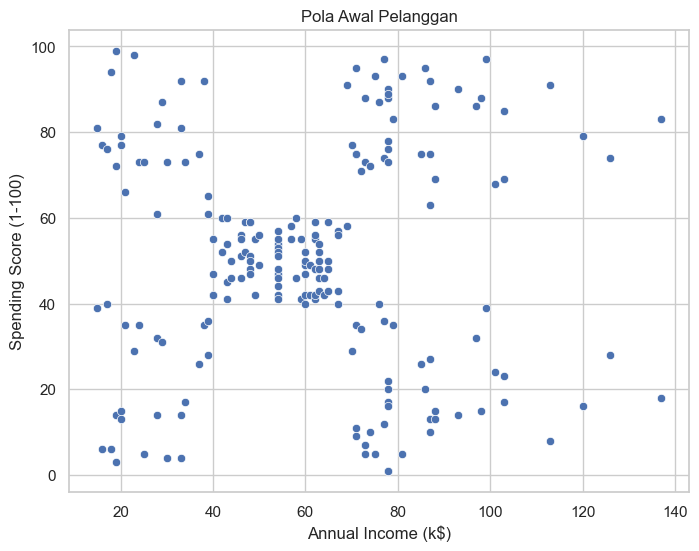

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)
plt.title("Pola Awal Pelanggan")
plt.show()

## 7. Standardisasi Data

K-Means menggunakan perhitungan jarak. Oleh karena itu, fitur-fitur perlu berada pada skala yang sebanding. Gunakan StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [37]:
print("Rata-rata setelah distandardisasi:")
print(X_scaled_df.mean())

print("\nStandar deviasi setelah distandardisasi:")
print(X_scaled_df.std())

Rata-rata setelah distandardisasi:
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standar deviasi setelah distandardisasi:
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


## 8. Elbow Method

K-Means membutuhkan nilai `K` sejak awal. Kita mencoba beberapa nilai `K` dan mencatat **inertia/WCSS**.

Inertia adalah jumlah jarak kuadrat data ke centroid cluster-nya. Kita mencari titik ketika penurunan inertia mulai melandai, seperti bentuk siku.

In [23]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

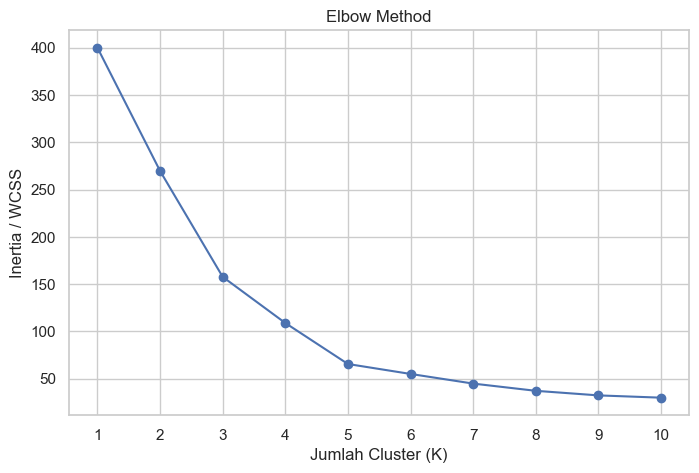

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia / WCSS")
plt.xticks(list(K_range))
plt.show()

## 9. Silhouette Score

Silhouette Score membantu menilai kualitas pemisahan cluster.

- Mendekati `1`: cluster semakin baik.
- Mendekati `0`: data berada di antara dua cluster.
- Negatif: data mungkin lebih dekat ke cluster lain.

Kita hitung skor untuk beberapa nilai `K`.

In [21]:
silhouette_scores = []
K_range_silhouette = range(2, 11)

for k in K_range_silhouette:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_temp = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": list(K_range_silhouette),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,K,Silhouette Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


### Analisis Silhoutte Score

Silhouette Score berada pada rentang -1 hingga 1. Semakin tinggi skornya (mendekati 1), berarti kluster yang terbentuk terpisah dengan sangat baik, padat, dan tidak tumpang tindih dengan kluster lain.

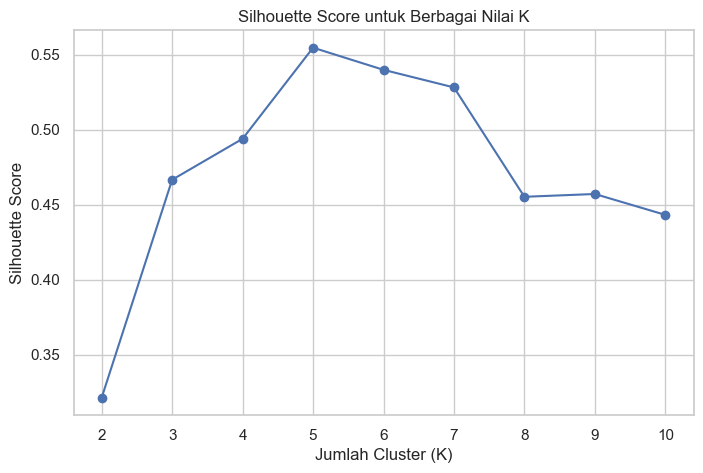

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette Score"],
    marker="o"
)
plt.title("Silhouette Score untuk Berbagai Nilai K")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range_silhouette))
plt.show()

### Analisis Grafik Output Silhouette Score

Grafik menunjukkan titik tertinggi berada pada angka 5 dengan Silhouette Score mencapai sekitar 0.55. Ini adalah indikator terkuat bahwa jumlah kluster optimal untuk data adalah 5.

Jika Anda memilih K = 2, 3, atau 4, skornya lebih rendah, yang berarti pembagian klusternya kurang optimal (ada data yang harusnya terpisah malah tergabung). Jika memilih K = 6 hingga 10, skornya cenderung menurun drastis, maka penambahan kluster membuat pemisahan antar kelompok menjadi over-clustering.

## 10. Implementasi K-Means

Jika hasil Elbow Method atau Silhouette Score sebelumnya menunjukkan nilai yang masih belum optimal (bukan K=5), maka ubah nilai `optimal_k` di bawah dan jalankan kembali.

In [28]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 11. Jumlah Anggota Tiap Cluster

In [38]:
cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

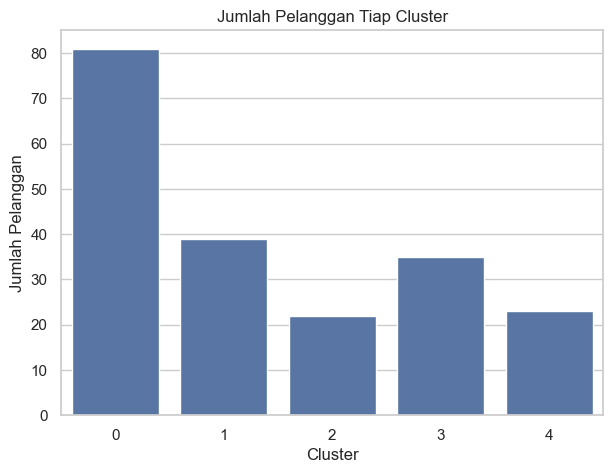

In [39]:
plt.figure(figsize=(7, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Jumlah Pelanggan Tiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Pelanggan")
plt.show()

## 12. Visualisasi Hasil Clustering

Proses clustering dilakukan pada data yang telah distandarisasi, tetapi grafik menggunakan skala asli agar lebih mudah dibaca.

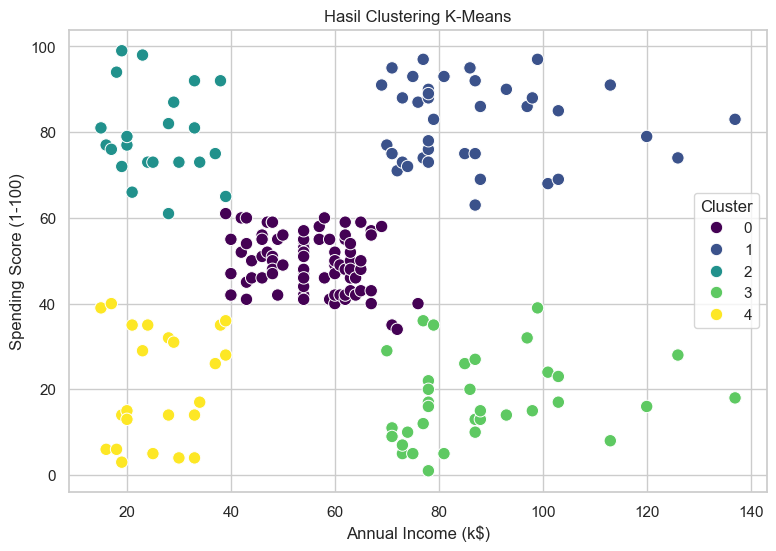

In [40]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=80
)
plt.title("Hasil Clustering K-Means")
plt.legend(title="Cluster")
plt.show()

### Menampilkan Centroid

Centroid adalah nilai tengah dari suatu klaster. Saat ini, centroid masih berada dalam skala standardisasi. Kembalikan ke skala asli terlebih dahulu menggunakan `inverse_transform`.

In [41]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)

centroids_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


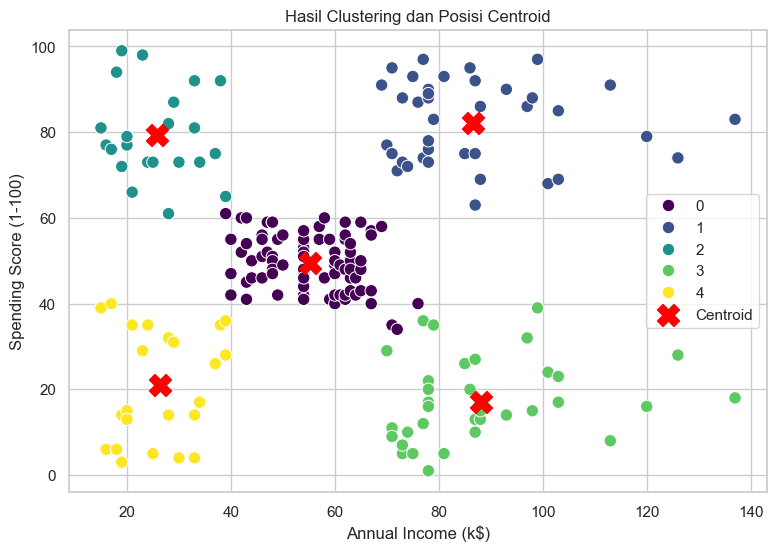

In [42]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.scatter(
    centroids_df["Annual Income (k$)"],
    centroids_df["Spending Score (1-100)"],
    marker="X",
    s=250,
    c="red",
    label="Centroid"
)

plt.title("Hasil Clustering dan Posisi Centroid")
plt.legend()
plt.show()


## 13. Evaluasi Model

In [44]:
final_silhouette = silhouette_score(X_scaled, labels)
print("Silhouette Score model akhir:", round(final_silhouette, 4))

Silhouette Score model akhir: 0.5547


## 14. Interpretasi Karakteristik Cluster

Cluster masih berupa angka. Agar lebih bermakna, kita hitung rata-rata pendapatan, spending score, usia, dan jumlah pelanggan pada setiap cluster.

In [45]:
cluster_summary = df.groupby("Cluster").agg(
    jumlah_pelanggan=("CustomerID", "count"),
    rata_rata_usia=("Age", "mean"),
    rata_rata_pendapatan=("Annual Income (k$)", "mean"),
    rata_rata_spending=("Spending Score (1-100)", "mean")
).round(2)

cluster_summary


,jumlah_pelanggan,rata_rata_usia,rata_rata_pendapatan,rata_rata_spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


### Contoh Penamaan Segmen

Nama cluster harus didasarkan pada nilai rata-ratanya.

Misal:
- Pendapatan tinggi + spending tinggi -> **Pelanggan Sultan**
- Pendapatan tinggi + spending rendah -> **Pelanggan Mendang-Mending**
- Pendapatan rendah + spending tinggi -> **Pelanggan FOMO**
- Pendapatan rendah + spending rendah -> **Pelanggan Mode Survival**
- Pendapatan dan spending menengah -> **Pelanggan UMR**

Nomor cluster tidak selalu sama setiap kali model diubah, sehingga interpretasi harus melihat statistiknya.

## 15. Membantu Interpretasi dengan Kuantil

Sebagai alat bantu, gunakan kuantil pendapatan dan kuantil spending score sebagai cara sederhana untuk membaca posisi setiap cluster.

In [47]:
income_low = df["Annual Income (k$)"].quantile(0.33)
income_high = df["Annual Income (k$)"].quantile(0.66)

spending_low = df["Spending Score (1-100)"].quantile(0.33)
spending_high = df["Spending Score (1-100)"].quantile(0.66)

def kategori_sederhana(row):
    income = row["rata_rata_pendapatan"]
    spending = row["rata_rata_spending"]

    if (income_low <= income <= income_high) and (spending_low <= spending <= spending_high):
        return "Pelanggan UMR (Pendapatan Menengah - Spending Menengah)"
    elif income > income_high and spending > spending_high:
        return "Pelanggan Sultan (Pendapatan Tinggi - Spending Tinggi)"
    elif income > income_high and spending < spending_low:
        return "Pelanggan Mendang-Mending (Pendapatan Tinggi - Spending Rendah)"
    elif income < income_low and spending > spending_high:
        return "Pelanggan FOMO (Pendapatan Rendah - Spending Tinggi)"        
    else:
        return "Pelanggan Mode Survival (Pendapatan Rendah - Spending Rendah)"

cluster_summary["kategori_sederhana"] = cluster_summary.apply(
    kategori_sederhana,
    axis=1
)

cluster_summary

,jumlah_pelanggan,rata_rata_usia,rata_rata_pendapatan,rata_rata_spending,kategori_sederhana
Cluster,,,,,
0,81,42.72,55.30,49.52,Pelanggan UMR (Pendapatan Menengah - Spending ...
1,39,32.69,86.54,82.13,Pelanggan Sultan (Pendapatan Tinggi - Spending...
2,22,25.27,25.73,79.36,Pelanggan FOMO (Pendapatan Rendah - Spending T...
3,35,41.11,88.20,17.11,Pelanggan Mendang-Mending (Pendapatan Tinggi -...
4,23,45.22,26.30,20.91,Pelanggan Mode Survival (Pendapatan Rendah - S...


## 16. Rekomendasi Strategi Pemasaran

Gunakan karakteristik cluster untuk menyusun strategi:

| Segmen | Karakteristik | Strategi |
|---|---|---|
| Pelanggan Sultan | Pendapatan tinggi, spending tinggi | Akses VIP pre-order dan undangan event eksklusif |
| Pelanggan Mendang-Mending | Pendapatan tinggi, spending rendah | Garansi jangka panjang dan jaminan harga termurah |
| Pelanggan FOMO | Pendapatan rendah, spending tinggi | Flash sale, produk viral, dan kupon Paylater |
| Pelanggan Mode Survival | Pendapatan rendah, spending rendah | Free ongkir tanpa minimum belanja dan diskon bundling super hemat |
| Pelanggan UMR | Pendapatan menengah, spending menengah | Payday promo setiap tanggal-bulan kembar |

Strategi akhir harus disesuaikan dengan hasil cluster pada dataset.

## 18. Alur

```text
Pilih Annual Income dan Spending Score
    ↓
Standardisasi
    ↓
Elbow Method dan Silhouette Score
    ↓
Jalankan K-Means
    ↓
Tambahkan label cluster
    ↓
Visualisasi dan evaluasi
    ↓
Interpretasi segmen
    ↓
Rekomendasi
```